## Loading of data

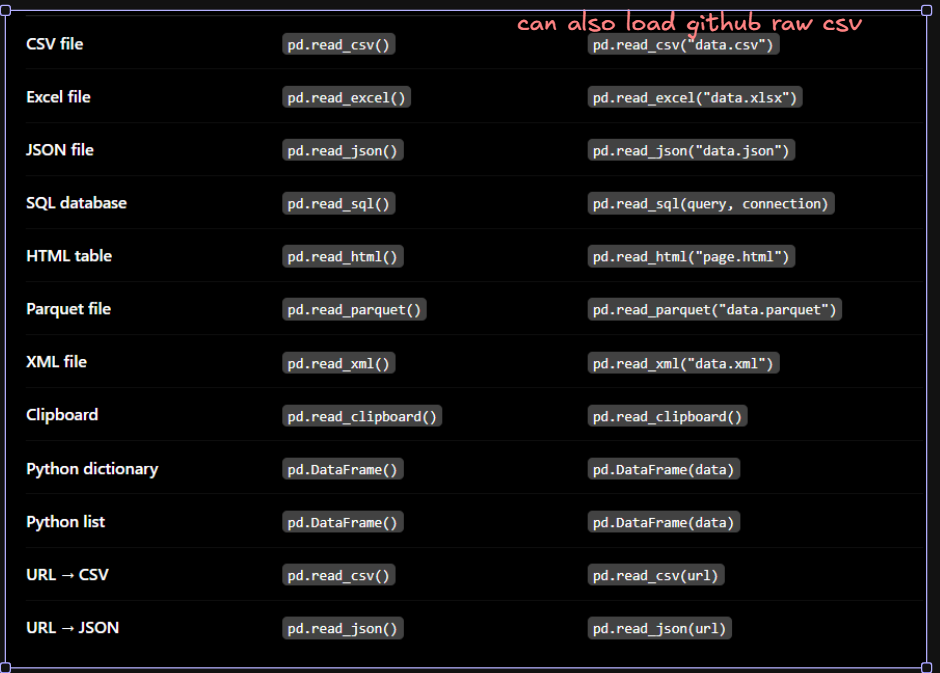

In [184]:
import pandas as pd
import numpy as np

In [185]:
df = pd.read_csv(r'anime.csv')  #--> r"" raw string to dective escape seq if happens

In [186]:
df.head()

,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05


## Creating a sep col for Episodes - `Learing: df["col"].str.replace() and df["col"].astype(int)`

In [187]:
# wanna create seperate episode cols 
df.loc[2]["Title"]

'Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 - Dec 2022474,138 members'

In [188]:
#observation: ep are written within ()
def extract_epesode(txt):
    ep = txt.split('(')[1].split(')')[0]
    return ep

In [189]:
# episode_list = list(map(extract_epesode, df["Title"]))
df["Episodes"] = df["Title"].apply(extract_epesode)

In [190]:
# removing eps so that we can perform nuemeric operations
df["Episodes"] = df["Episodes"].str.replace(" eps", "")

In [191]:
# still the episodes are str so converto to int
df["Episodes"] = df['Episodes'].astype(int)

## make a new col for timestamps

In [192]:
df

,Rank,Title,Score,Episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13


In [193]:
df.loc[0]["Title"]
# )Apr 2009 - Jul 20103,

'Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview'

In [194]:
def extract_timestamp(txt):
    time = txt.split(')')[1][:19]
    return time

In [195]:
df["Timestamp"] = df["Title"].apply(extract_timestamp)

In [196]:
df

,Rank,Title,Score,Episodes,Timestamp
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51,Apr 2011 - Mar 2012
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1,Jan 2021 - Jan 2021
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148,Oct 2011 - Sep 2014
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13,Apr 2022 - Jun 2022
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13,Oct 2012 - Mar 2013


In [197]:
def calculate_months(timestamp):
    start, end = timestamp.split(" - ")

    start = pd.to_datetime(start, format="%b %Y")
    end = pd.to_datetime(end, format="%b %Y")

    return (end.year - start.year) * 12 + (end.month - start.month)

df["Months"] = df["Timestamp"].apply(calculate_months)

In [198]:
df

,Rank,Title,Score,Episodes,Timestamp,Months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010,15
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011,5
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022,2
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016,11
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019,3
5,6,"Gintama'TV (51 eps)Apr 2011 - Mar 2012534,105 ...",9.04,51,Apr 2011 - Mar 2012,11
6,7,Gintama: The FinalMovie (1 eps)Jan 2021 - Jan ...,9.04,1,Jan 2021 - Jan 2021,0
7,8,Hunter x Hunter TV (148 eps)Oct 2011 - Sep 201...,9.04,148,Oct 2011 - Sep 2014,35
8,9,Kaguya-sama wa Kokurasetai: Ultra RomanticTV (...,9.04,13,Apr 2022 - Jun 2022,2
9,10,Gintama': EnchousenTV (13 eps)Oct 2012 - Mar 2...,9.03,13,Oct 2012 - Mar 2013,5


## which anime has highest score

In [199]:
df[df["Score"] == df["Score"].max()]['Title']

0    Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...
Name: Title, dtype: str

### top 5 anime 

In [200]:
df["Title"].head()

0    Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...
1    Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...
2    Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...
3    Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...
4    Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...
Name: Title, dtype: str

### Which anime has the highest number of epesodes 

In [201]:
df.head()

,Rank,Title,Score,Episodes,Timestamp,Months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,64,Apr 2009 - Jul 2010,15
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,24,Apr 2011 - Sep 2011,5
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,13,Oct 2022 - Dec 2022,2
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,51,Apr 2015 - Mar 2016,11
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,10,Apr 2019 - Jul 2019,3


In [205]:
df[df["Episodes"] == df["Episodes"].max()]["Title"]

15    GintamaTV (201 eps)Apr 2006 - Mar 20101,034,41...
Name: Title, dtype: str

### Longest running anime

In [209]:
df[df["Months"] == df["Months"].max()]

,Rank,Title,Score,Episodes,Timestamp,Months
11,12,Ginga Eiyuu DensetsuOVA (110 eps)Jan 1988 - Ma...,9.02,110,Jan 1988 - Mar 1997,110
